In [1]:
from pathlib import Path
import sys

code_dir = Path('/workspace/gdp-hmm-model')
sys.path.append(str(code_dir)) # Need to be string
sys.path.append(str(code_dir/'mednext'))

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from nnunet_mednext import create_mednext_v1
import yaml
from pprint import pprint

from tqdm import tqdm
import numpy as np

In [3]:
%load_ext autoreload
%autoreload 2

import data_loader



In [4]:
cfig = yaml.load(open(code_dir / 'config_files/config.yaml'), Loader=yaml.FullLoader)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
model = create_mednext_v1( num_input_channels = 7,
  num_classes = cfig['model_params']['out_channels'],
  model_id = cfig['model_params']['model_id'],          # S, B, M and L are valid model ids
  kernel_size = cfig['model_params']['kernel_size'],   # 3x3x3 and 5x5x5 were tested in publication
  deep_supervision = cfig['model_params']['deep_supervision']
).to(device)

model.load_state_dict(torch.load('weights/7c_v2.pt'))

<All keys matched successfully>

In [6]:
from pathlib import Path
import numpy as np
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# Fixed length, random sampled
# extra param: size -> size of the dataset

class ChallengeData(Dataset):
    def __init__(self, data_dir, ids, size=None):
        super().__init__()
        self.data_dir = Path(data_dir)
        self.ids = ids
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.size = size if size is not None else len(ids)
        self._sample()

    def __len__(self):
        return self.size

    def _sample(self):
        if self.size < len(self.ids):
            self.current_ids = np.random.choice(self.ids, self.size, replace=False).tolist()
            print('Dataset resampled')
        else:
            self.current_ids = self.ids.copy()
            print('Dataset all samples used')

    def __getitem__(self, idx):
        npz_path = self.data_dir / f'{self.current_ids[idx]}.npz'

        data_dict = dict(np.load(npz_path))

        # Unsqueeze the 1st dim: x -> (8, 96, 128, 144)
        x = torch.from_numpy(data_dict['data'])[0].to(self.device)
        y = torch.from_numpy(data_dict['label'])[0].to(self.device)

        # Mask, derived from x
        body_mask = x[3:4,...].bool()
        outbody_mask = ~body_mask
        ptv_mask = x[1:2, ...].bool()
        near_mask = torch.logical_and(~ptv_mask, body_mask)

        if idx==self.size-1: self._sample()

        info = x[-1].mean((1, 2))[:4].cpu().tolist()
        info = torch.tensor(info).to(self.device)
            
        return x[:-1], y, body_mask, outbody_mask, ptv_mask, near_mask, info



In [8]:
from sklearn.model_selection import train_test_split

others, test_ids = train_test_split(range(2728), test_size=0.3, random_state=1234)
train_ids, val_ids = train_test_split(others, test_size=0.3, random_state=1234)

In [9]:
batch_size = 16

data_tr = ChallengeData('/workspace/data/train_data_dict', train_ids, size=1000)
loader_tr = DataLoader(data_tr, batch_size=batch_size, shuffle=False)

data_vl = ChallengeData('/workspace/data/train_data_dict', val_ids, size=100)
loader_vl = DataLoader(data_vl, batch_size=batch_size, shuffle=False)

data_ts = ChallengeData('/workspace/data/train_data_dict', test_ids)
loader_ts = DataLoader(data_ts, batch_size=1, shuffle=False)


Dataset resampled
Dataset resampled
Dataset all samples used


In [10]:
def cal_error(pred, gt, body):
    isodose_5Gy_mask = ((gt > 0.5) | (pred > 0.5)) & (body > 0)
    isodose_ref_5Gy_mask = (gt > 0.5) & (body > 0)
    diff = gt - pred
    error = torch.sum(torch.abs(diff)[isodose_5Gy_mask > 0]) / torch.sum(isodose_ref_5Gy_mask)
    return error

def custom_loss(outputs, y, body_mask, outbody_mask, ptv_mask, near_mask, _id):
    if _id == 1:
        loss = criterion(outputs, y)
    if _id == 2:
        loss = criterion(outputs[body_mask], y[body_mask])
    if _id == 3:
        loss = criterion(outputs[body_mask], y[body_mask]) + 5 * criterion(outputs[near_mask], y[near_mask])
    if _id == 4:
        loss = cal_error(outputs, y, body_mask) + criterion(outputs, y) + torch.max(outputs[outbody_mask])

    return loss

def iso_5_dice(pred, gt, body):
    iso_mask = ((gt > 0.5) | (pred > 0.5)) & (body > 0)
    iso_mask_gt = (gt > 0.5) & (body > 0)
    return 2*(iso_mask*iso_mask_gt).sum() / (iso_mask.sum() + iso_mask_gt.sum())

def img_grad(img):
    return img[..., :-1, :-1, :-1] - img[..., 1:, 1:, 1:]

def cal_grad_loss(pred, y, mask):
    _mask = mask[..., :-1, :-1, :-1]
    return criterion(img_grad(pred)[_mask], img_grad(y)[_mask])
    

# Model

In [11]:
class SmoothModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = torch.nn.Conv3d(4, 64, kernel_size=3, padding='same', bias=False)
        self.conv2 = torch.nn.Conv3d(64, 32, kernel_size=5, padding='same', bias=False)
        self.conv3 = torch.nn.Conv3d(32, 16, kernel_size=7, padding='same', bias=False)
        self.conv4 = torch.nn.Conv3d(16, 1, kernel_size=5, padding='same', bias=False)
        
        self.bp1 = torch.nn.Conv3d(1, 16, kernel_size=5, padding='same', bias=False)
        self.bp2 = torch.nn.Conv3d(16, 1, kernel_size=5, padding='same', bias=False)

        self.smooth = torch.nn.Conv3d(1, 1, kernel_size=3, padding='same', bias=False)
        self.relu = torch.nn.ReLU()

    def forward(self, x_, beam_plate):

        x = self.conv1(x_)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.relu(x)
        
        x = self.conv3(x)
        x = self.relu(x)

        x = self.conv4(x)
        x = self.relu(x)

        beam_plate = self.bp1(beam_plate)
        beam_plate = self.relu(beam_plate)
        beam_plate = self.bp2(beam_plate)
        beam_plate = self.relu(beam_plate)

        out = x_[:,0:1,...] + x + beam_plate

        out = self.smooth(out)

        return out

s_model = SmoothModel().to(device)
model.eval()
s_model.train()

SmoothModel(
  (conv1): Conv3d(4, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=same, bias=False)
  (conv2): Conv3d(64, 32, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=same, bias=False)
  (conv3): Conv3d(32, 16, kernel_size=(7, 7, 7), stride=(1, 1, 1), padding=same, bias=False)
  (conv4): Conv3d(16, 1, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=same, bias=False)
  (bp1): Conv3d(1, 16, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=same, bias=False)
  (bp2): Conv3d(16, 1, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=same, bias=False)
  (smooth): Conv3d(1, 1, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=same, bias=False)
  (relu): ReLU()
)

In [22]:
optimizer = optim.Adam(s_model.parameters(), lr=1e-4)
criterion = nn.L1Loss()
epochs = 10

In [23]:
loss_id = 3

In [ ]:
for epoch in range(epochs):
    
    pbar = tqdm(loader_tr, f'Epoch {epoch}')
    
    train_loss = []
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in pbar:
        
      # Forward pass
      with torch.no_grad():
          x_ = model(x)
          site = info[:,2].view((info.size(0),1,1,1,1))*torch.ones((1,1,96,128,144)).to('cuda')
          beam_plate = x[:,5:6, ...]
          x_ = torch.concat([x_, body_mask, ptv_mask, site], 1)
      
      outputs = s_model(x_, beam_plate)

      if loss_id == 1:
        loss = criterion(outputs, y)
      if loss_id == 2:
        loss = criterion(outputs[body_mask], y[body_mask])
      if loss_id == 3:
        loss = 1 * criterion(outputs[body_mask], y[body_mask]) + \
               10 * criterion(outputs[near_mask], y[near_mask]) + \
               1 * cal_error(outputs, y, body_mask) 
               # 30*iso_5_dice(outputs, y, body_mask) + \
              # 10 * criterion(outputs[outbody_mask], y[outbody_mask])
    
      if loss_id == 4:
        loss = cal_error(outputs, y, body_mask) + criterion(outputs, y) + torch.max(outputs[outbody_mask])

      if loss_id == 5:
        loss = 1 * cal_error(outputs, y, body_mask)  + \
               50 * cal_grad_loss(outputs, y, body_mask)
    
      # Backward pass and optimization
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    
      train_loss.append(loss.detach().cpu().item())
      pbar.set_postfix_str(f'Loss: {loss.item():.3f}')
    
    val_loss = []
    model.eval()
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in loader_vl:
        with torch.no_grad():
            x_ = model(x)
            site = info[:,2].view((info.size(0),1,1,1,1))*torch.ones((1,1,96,128,144)).to('cuda')
            beam_plate = x[:,5:6, ...]
            x_ = torch.concat([x_, body_mask, ptv_mask, site], 1)
      
            outputs = s_model(x_, beam_plate)
            loss = cal_error(outputs, y, body_mask)
            val_loss.append(loss.detach().cpu().item())
    
    print(f'Train loss: {np.mean(train_loss):.3f} ({np.std(train_loss):.3f}) '+ \
          f'Val loss: {np.mean(val_loss):.3f} ({np.std(val_loss):.3f})')


Epoch 0:  98%|█████████▊| 62/63 [05:04<00:04,  4.92s/it, Loss: 2.526]

Dataset resampled


Epoch 0: 100%|██████████| 63/63 [05:06<00:00,  4.87s/it, Loss: 2.166]


Dataset resampled
Train loss: 2.332 (0.244) Val loss: 0.340 (0.014)


Epoch 1:  98%|█████████▊| 62/63 [05:04<00:04,  4.89s/it, Loss: 1.920]

...

Epoch 8:  98%|█████████▊| 62/63 [05:04<00:04,  4.91s/it, Loss: 2.460]

Dataset resampled


Epoch 8: 100%|██████████| 63/63 [05:06<00:00,  4.87s/it, Loss: 2.322]


Dataset resampled
Train loss: 2.320 (0.281) Val loss: 0.356 (0.024)


Epoch 9:  27%|██▋       | 17/63 [01:23<03:45,  4.91s/it, Loss: 2.503]

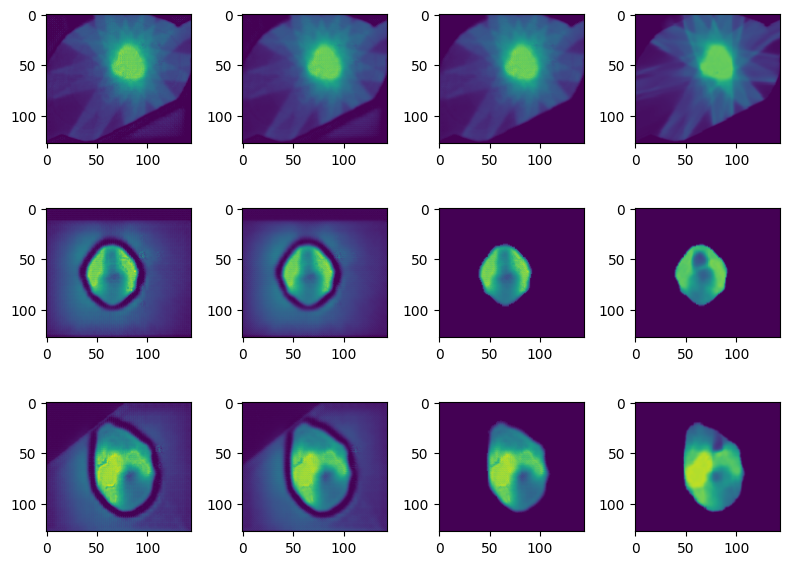

In [21]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3, 4, figsize=(8, 6))

out_masked = outputs.clone()
out_masked[body_mask==False] = 0

for i in range(3):
    ax[i,0].imshow(x_[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,1].imshow(outputs[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,2].imshow(out_masked[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,3].imshow(y.cpu()[i,0,50], vmin=0, vmax=8)
plt.tight_layout()

In [140]:
ts_loss = []
model.eval()

pbar = tqdm(loader_ts)
for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in pbar:
    with torch.no_grad():
        x_ = model(x)
        site = info[:,2].view((info.size(0),1,1,1,1))*torch.ones((1,1,96,128,144)).to('cuda')
        beam_plate = x[:,5:6, ...]
        x_ = torch.concat([x_, body_mask, ptv_mask, site], 1)
        outputs = s_model(x_, beam_plate)
        # loss = criterion(outputs, y)
        
        loss = cal_error(outputs, y, body_mask)
        ts_loss.append(loss.detach().cpu().item())
        pbar.set_postfix_str(f'Test loss: {np.mean(ts_loss):.3f}')



100%|█████████▉| 818/819 [03:32<00:00,  3.53it/s, Test loss: 0.344]

Dataset all samples used


100%|██████████| 819/819 [03:33<00:00,  3.84it/s, Test loss: 0.344]


In [141]:
torch.save(s_model.state_dict(), 'weights/smooth_v1.pt') # Test loss: 0.344

In [142]:
s_model.load_state_dict(torch.load('weights/smooth_v1.pt'))

<All keys matched successfully>

# Model 2

In [37]:
from models import MLP

b_model = MLP().to(device)
b_model.eval()
b_model.load_state_dict(torch.load('weights/bias.pt'))

<All keys matched successfully>

In [94]:
class SmoothModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = torch.nn.Conv3d(5, 64, kernel_size=3, padding='same')
        self.conv2 = torch.nn.Conv3d(64, 32, kernel_size=5, padding='same')
        self.conv3 = torch.nn.Conv3d(32, 16, kernel_size=7, padding='same')
        self.conv4 = torch.nn.Conv3d(16, 1, kernel_size=5, padding='same')
        
        self.bp1 = torch.nn.Conv3d(1, 16, kernel_size=5, padding='same')
        self.bp2 = torch.nn.Conv3d(16, 1, kernel_size=5, padding='same')

        self.smooth = torch.nn.Conv3d(3, 1, kernel_size=3, padding='same', bias=False)
        self.relu = torch.nn.ReLU()

    def forward(self, x_, beam_plate):

        x = self.conv1(x_)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.conv3(x)
        x = self.relu(x)
        x = self.conv4(x)
        x = self.relu(x)

        beam_plate = self.bp1(beam_plate)
        beam_plate = self.relu(beam_plate)
        beam_plate = self.bp2(beam_plate)
        beam_plate = self.relu(beam_plate)

        out = torch.concat([x_[:,0:1,...], x, beam_plate], -4)
        print(out.shape)

        out = self.smooth(out)

        return out

s_model = SmoothModel().to(device)
model.eval()
s_model.train()

SmoothModel(
  (conv1): Conv3d(5, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=same)
  (conv2): Conv3d(64, 32, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=same)
  (conv3): Conv3d(32, 16, kernel_size=(7, 7, 7), stride=(1, 1, 1), padding=same)
  (conv4): Conv3d(16, 1, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=same)
  (bp1): Conv3d(1, 16, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=same)
  (bp2): Conv3d(16, 1, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=same)
  (smooth): Conv3d(3, 1, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=same, bias=False)
  (relu): ReLU()
)

In [95]:
optimizer = optim.Adam(s_model.parameters(), lr=1e-3)
criterion = nn.L1Loss()
epochs = 10

In [96]:
loss_id = 3

In [97]:
ones = torch.ones((1,1,96,128,144)).to('cuda')

for epoch in range(20):
    s_model.train()
    pbar = tqdm(loader_tr, f'Epoch {epoch}')
    
    train_loss = []
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in pbar:
        
      # Forward pass
      with torch.no_grad():
          bias = b_model(info)
          masks = torch.concat([body_mask, ptv_mask, near_mask], 1)
          bias_masks = bias.view((*bias.size(),1,1,1)) * masks
          
          site = info[:,2].view((info.size(0),1,1,1,1))*torch.ones((1,1,96,128,144)).to('cuda')
          
          x_ = model(x)
          
          beam_plate = x[:,5:6, ...]
          
          x_ = torch.concat([x_, bias_masks, site], 1)
      
      outputs = s_model(x_, beam_plate)

      if loss_id == 1:
        loss = criterion(outputs, y)
      if loss_id == 2:
        loss = criterion(outputs[body_mask], y[body_mask])
      if loss_id == 3:
        loss = 1 * criterion(outputs[body_mask], y[body_mask]) + \
               10 * criterion(outputs[near_mask], y[near_mask]) + \
               1 * cal_error(outputs, y, body_mask) 
               # 30*iso_5_dice(outputs, y, body_mask) + \
              # 10 * criterion(outputs[outbody_mask], y[outbody_mask])
    
      if loss_id == 4:
        loss = cal_error(outputs, y, body_mask) + criterion(outputs, y) + torch.max(outputs[outbody_mask])

      if loss_id == 5:
        loss = 1 * cal_error(outputs, y, body_mask)  + \
               50 * cal_grad_loss(outputs, y, body_mask)
    
      # Backward pass and optimization
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    
      train_loss.append(loss.detach().cpu().item())
      pbar.set_postfix_str(f'Loss: {loss.item():.3f}')
    
    val_loss = []
    s_model.eval()
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in loader_vl:
        with torch.no_grad():
            bias = b_model(info)
            masks = torch.concat([body_mask, ptv_mask, near_mask], 1)
            bias_masks = bias.view((*bias.size(),1,1,1)) * masks
            site = info[:,2].view((info.size(0),1,1,1,1))*torch.ones((1,1,96,128,144)).to('cuda')
            x_ = model(x)
            beam_plate = x[:,5:6, ...]
            x_ = torch.concat([x_, bias_masks, site], 1)
            outputs = s_model(x_, beam_plate)
            
            loss = cal_error(outputs, y, body_mask)
            val_loss.append(loss.detach().cpu().item())
    
    print(f'Train loss: {np.mean(train_loss):.3f} ({np.std(train_loss):.3f}) '+ \
          f'Val loss: {np.mean(val_loss):.3f} ({np.std(val_loss):.3f})')


Epoch 0:   0%|          | 0/63 [00:02<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 13.16 GiB. GPU 0 has a total capacty of 79.14 GiB of which 2.91 GiB is free. Process 1772396 has 76.22 GiB memory in use. Of the allocated memory 59.31 GiB is allocated by PyTorch, and 16.40 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

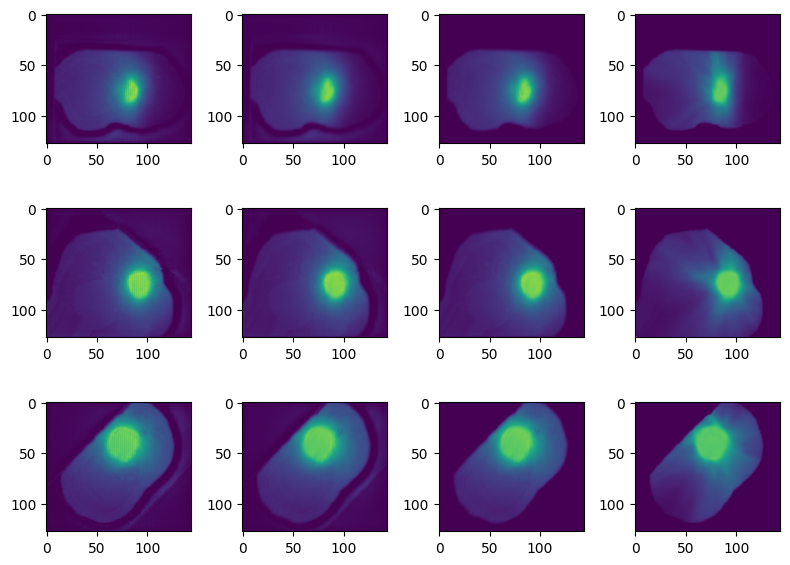

In [81]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3, 4, figsize=(8, 6))

out_masked = outputs.clone()
out_masked[body_mask==False] = 0

for i in range(3):
    ax[i,0].imshow(x_[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,1].imshow(outputs[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,2].imshow(out_masked[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,3].imshow(y.cpu()[i,0,50], vmin=0, vmax=8)
plt.tight_layout()

In [ ]:
ts_loss = []
model.eval()

pbar = tqdm(loader_ts)
for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in pbar:
    with torch.no_grad():
        x = model(x)
        outputs = s_model(x)
        # loss = criterion(outputs, y)
        
        loss = cal_error(outputs, y, body_mask)
        ts_loss.append(loss.detach().cpu().item())
        pbar.set_postfix_str(f'Test loss: {np.mean(ts_loss):.3f}')



In [ ]:
# torch.save(s_model.state_dict(), 'weights/smooth_v1.pt') 
# s_model.load_state_dict(torch.load('weights/smooth_v1.pt'))
